# Customer Insight - 100.000 rows

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

In [2]:
FILE_PATH = "./customers-2000000.csv"
df = pd.read_csv(FILE_PATH)
df.head()

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website
0,1,4962fdbE6Bfee6D,Pam,Sparks,Patel-Deleon,Blakemouth,British Indian Ocean Territory (Chagos Archipe...,267-243-9490x035,480-078-0535x889,nicolas00@faulkner-kramer.com,2020-11-29,https://nelson.com/
1,2,9b12Ae76fdBc9bE,Gina,Rocha,"Acosta, Paul and Barber",East Lynnchester,Costa Rica,027.142.0940,+1-752-593-4777x07171,yfarley@morgan.com,2021-01-03,https://pineda-rogers.biz/
2,3,39edFd2F60C85BC,Kristie,Greer,Ochoa PLC,West Pamela,Ecuador,+1-049-168-7497x5053,+1-311-216-7855,jennyhayden@petty.org,2021-06-20,https://mckinney.com/
3,4,Fa42AE6a9aD39cE,Arthur,Fields,Moyer-Wang,East Belinda,Afghanistan,001-653-754-7486x65787,521-630-3858x953,igrimes@ruiz-todd.org,2020-02-13,https://dominguez.biz/
4,5,F5702Edae925F1D,Michelle,Blevins,Shah and Sons,West Jared,Marshall Islands,8735278329,(633)283-6034x500,diamondcarter@jordan.com,2020-10-20,http://murillo-ryan.com/


# Parsing using Pandas

In [3]:
pandas_memory = df.memory_usage(deep=True).sum() / (1024**2)
print(f"Pandas original read_csv: {pandas_memory:.2f} MB")

Pandas original read_csv: 1506.04 MB


# Parsing using Chunking

In [4]:
chunk_size = 100000
total_memory_usage = 0
for chunk in pd.read_csv(FILE_PATH, chunksize=chunk_size):
    print(f"Chunk memory usage: {chunk.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
    total_memory_usage += chunk.memory_usage(deep=True).sum() / (1024**2)

print(f"Chunking total memory: {total_memory_usage:.2f} MB")

Chunk memory usage: 75.30 MB
Chunk memory usage: 75.29 MB
Chunk memory usage: 75.30 MB
Chunk memory usage: 75.31 MB
Chunk memory usage: 75.30 MB
Chunk memory usage: 75.30 MB
Chunk memory usage: 75.31 MB
Chunk memory usage: 75.31 MB
Chunk memory usage: 75.31 MB
Chunk memory usage: 75.30 MB
Chunk memory usage: 75.31 MB
Chunk memory usage: 75.31 MB
Chunk memory usage: 75.30 MB
Chunk memory usage: 75.30 MB
Chunk memory usage: 75.29 MB
Chunk memory usage: 75.29 MB
Chunk memory usage: 75.31 MB
Chunk memory usage: 75.30 MB
Chunk memory usage: 75.30 MB
Chunk memory usage: 75.30 MB
Chunking total memory: 1506.04 MB


# Parsing using Memory Optimization

In [5]:
optimized_dtypes ={
    "Index": "int32",
    "Customer Id": "object",
    "First Name": "object",
    "Last Name": "object",
    "Company": "category",
    "City": "category",
    "Country": "category",
    "Phone 1": "object",
    "Phone 2": "object",
    "Email": "object",
    "Subscription Date": "object",
    "Website": "category"
}

# 3. LOAD THE DATAFRAME
df = pd.read_csv(
    FILE_PATH,
    dtype=optimized_dtypes,
)

memory_usage_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Total Memory Usage: {memory_usage_mb:.2f} MB")

Total Memory Usage: 1171.17 MB


# Data Quality Check

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 12 columns):
 #   Column             Dtype   
---  ------             -----   
 0   Index              int32   
 1   Customer Id        object  
 2   First Name         object  
 3   Last Name          object  
 4   Company            category
 5   City               category
 6   Country            category
 7   Phone 1            object  
 8   Phone 2            object  
 9   Email              object  
 10  Subscription Date  object  
 11  Website            category
dtypes: category(4), int32(1), object(7)
memory usage: 208.4+ MB


In [7]:
duplicates = df.duplicated(subset=['Customer Id']).sum()
print(f"Found {duplicates} duplicate Customer IDs.")
if duplicates > 0:
    df = df.drop_duplicates(subset=['Customer Id'])
    print(f"Dropped duplicates. New row count: {len(df)}")

Found 0 duplicate Customer IDs.


In [8]:
print("\nMissing values per column:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])


Missing values per column:
Series([], dtype: int64)


In [9]:
def clean_phone_format(phone_str):
    phone_str = str(phone_str).lower()

    cleaned = re.sub(r'[^0-9x+]', '', phone_str)
    cleaned = cleaned.replace('x', ' ext ')
    
    return cleaned

df['Clean_Phone_1'] = df['Phone 1'].apply(clean_phone_format)
df['Clean_Phone_2'] = df['Phone 2'].apply(clean_phone_format)
df[['Phone 1', 'Clean_Phone_1', 'Phone 2', 'Clean_Phone_2']].head(10)

,Phone 1,Clean_Phone_1,Phone 2,Clean_Phone_2
0,267-243-9490x035,2672439490 ext 035,480-078-0535x889,4800780535 ext 889
1,027.142.0940,0271420940,+1-752-593-4777x07171,+17525934777 ext 07171
2,+1-049-168-7497x5053,+10491687497 ext 5053,+1-311-216-7855,+13112167855
3,001-653-754-7486x65787,0016537547486 ext 65787,521-630-3858x953,5216303858 ext 953
4,8735278329,8735278329,(633)283-6034x500,6332836034 ext 500
5,2382697028,2382697028,822-449-7638,8224497638
6,608.531.0005x630,6085310005 ext 630,926-957-7052x6181,9269577052 ext 6181
7,+1-391-505-2358,+13915052358,076.454.1128,0764541128
8,001-366-285-9819x5924,0013662859819 ext 5924,852.896.9192x3681,8528969192 ext 3681
9,951.359.7028x94651,9513597028 ext 94651,931.227.4541,9312274541


In [10]:
def clean_email(email_str):
    cleaned = str(email_str).strip().lower()
    return cleaned

def is_valid_email(email_str):
    email_regex = r'^[a-z0-9_.+-]+@[a-z0-9-]+\.[a-z0-9-.]+$'
    return bool(re.match(email_regex, email_str))


print("Cleaning and validating emails...")
df['Clean_Email'] = df['Email'].apply(clean_email)
df['Email_Is_Valid'] = df['Clean_Email'].apply(is_valid_email)

invalid_emails = len(df[df['Email_Is_Valid'] == False])
print(f"Found {invalid_emails} invalid or missing emails out of {len(df)}.")

df[['Email', 'Clean_Email', 'Email_Is_Valid']].head(10)

Cleaning and validating emails...
Found 0 invalid or missing emails out of 2000000.


,Email,Clean_Email,Email_Is_Valid
0,nicolas00@faulkner-kramer.com,nicolas00@faulkner-kramer.com,True
1,yfarley@morgan.com,yfarley@morgan.com,True
2,jennyhayden@petty.org,jennyhayden@petty.org,True
3,igrimes@ruiz-todd.org,igrimes@ruiz-todd.org,True
4,diamondcarter@jordan.com,diamondcarter@jordan.com,True
5,mannkiara@bowman.com,mannkiara@bowman.com,True
6,dlynn@palmer-morgan.com,dlynn@palmer-morgan.com,True
7,joy45@conner.org,joy45@conner.org,True
8,stacydavis@spencer.com,stacydavis@spencer.com,True
9,danhouston@moon.net,danhouston@moon.net,True


# Data Transformation

In [11]:
# Convert 'Subscription Date' from string to datetime
df['Subscription Date'] = pd.to_datetime(df['Subscription Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 16 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Index              int32         
 1   Customer Id        object        
 2   First Name         object        
 3   Last Name          object        
 4   Company            category      
 5   City               category      
 6   Country            category      
 7   Phone 1            object        
 8   Phone 2            object        
 9   Email              object        
 10  Subscription Date  datetime64[ns]
 11  Website            category      
 12  Clean_Phone_1      object        
 13  Clean_Phone_2      object        
 14  Clean_Email        object        
 15  Email_Is_Valid     bool          
dtypes: bool(1), category(4), datetime64[ns](1), int32(1), object(9)
memory usage: 256.1+ MB


In [12]:
df['Subscription Year-Month'] = df['Subscription Date'].dt.to_period('M')
df.head()

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website,Clean_Phone_1,Clean_Phone_2,Clean_Email,Email_Is_Valid,Subscription Year-Month
0,1,4962fdbE6Bfee6D,Pam,Sparks,Patel-Deleon,Blakemouth,British Indian Ocean Territory (Chagos Archipe...,267-243-9490x035,480-078-0535x889,nicolas00@faulkner-kramer.com,2020-11-29,https://nelson.com/,2672439490 ext 035,4800780535 ext 889,nicolas00@faulkner-kramer.com,True,2020-11
1,2,9b12Ae76fdBc9bE,Gina,Rocha,"Acosta, Paul and Barber",East Lynnchester,Costa Rica,027.142.0940,+1-752-593-4777x07171,yfarley@morgan.com,2021-01-03,https://pineda-rogers.biz/,0271420940,+17525934777 ext 07171,yfarley@morgan.com,True,2021-01
2,3,39edFd2F60C85BC,Kristie,Greer,Ochoa PLC,West Pamela,Ecuador,+1-049-168-7497x5053,+1-311-216-7855,jennyhayden@petty.org,2021-06-20,https://mckinney.com/,+10491687497 ext 5053,+13112167855,jennyhayden@petty.org,True,2021-06
3,4,Fa42AE6a9aD39cE,Arthur,Fields,Moyer-Wang,East Belinda,Afghanistan,001-653-754-7486x65787,521-630-3858x953,igrimes@ruiz-todd.org,2020-02-13,https://dominguez.biz/,0016537547486 ext 65787,5216303858 ext 953,igrimes@ruiz-todd.org,True,2020-02
4,5,F5702Edae925F1D,Michelle,Blevins,Shah and Sons,West Jared,Marshall Islands,8735278329,(633)283-6034x500,diamondcarter@jordan.com,2020-10-20,http://murillo-ryan.com/,8735278329,6332836034 ext 500,diamondcarter@jordan.com,True,2020-10


# Insights

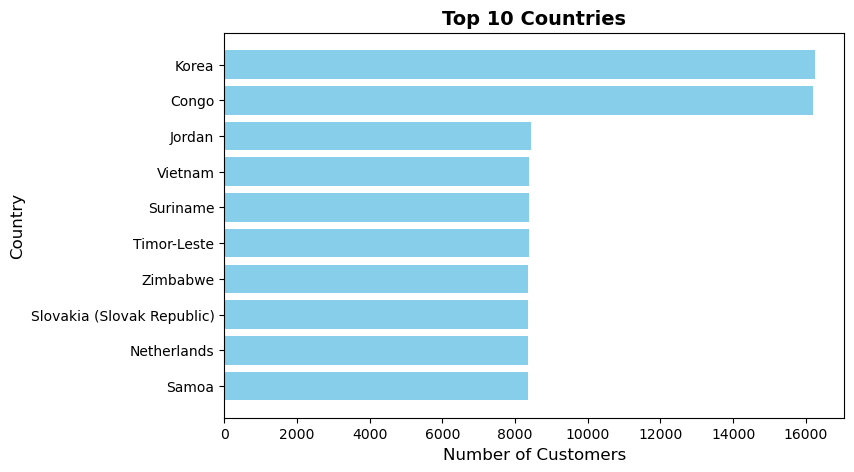

Korea                         16240
Congo                         16208
Jordan                         8428
Vietnam                        8388
Suriname                       8375
Timor-Leste                    8372
Zimbabwe                       8360
Slovakia (Slovak Republic)     8359
Netherlands                    8354
Samoa                          8354
Name: Country, dtype: int64


In [13]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(8, 5))

plt.barh(top_countries.index, top_countries.values, color='skyblue')
plt.gca().invert_yaxis()

plt.title('Top 10 Countries', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Country', fontsize=12)

plt.show()
print(top_countries)

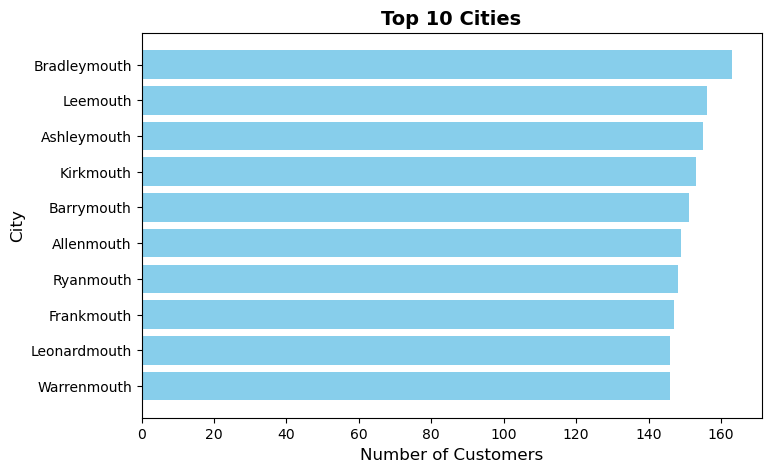

Bradleymouth    163
Leemouth        156
Ashleymouth     155
Kirkmouth       153
Barrymouth      151
Allenmouth      149
Ryanmouth       148
Frankmouth      147
Leonardmouth    146
Warrenmouth     146
Name: City, dtype: int64


In [14]:
top_cities = df['City'].value_counts().head(10)

plt.figure(figsize=(8, 5))

plt.barh(top_cities.index, top_cities.values, color='skyblue')
plt.gca().invert_yaxis()

plt.title('Top 10 Cities', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('City', fontsize=12)

plt.show()
print(top_cities)

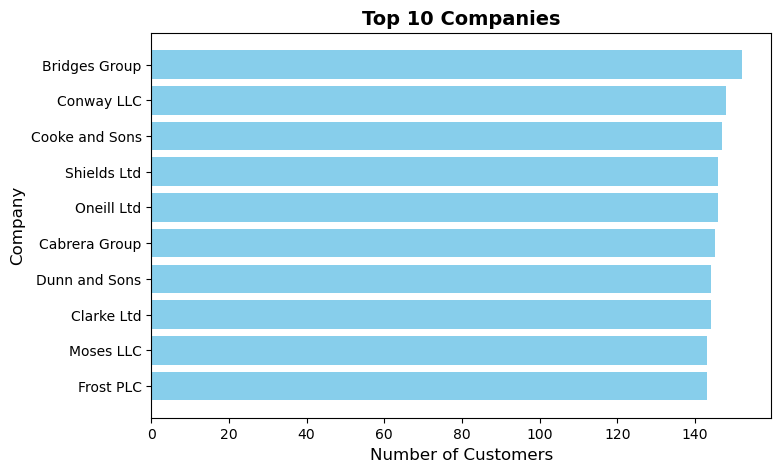

Bridges Group     152
Conway LLC        148
Cooke and Sons    147
Shields Ltd       146
Oneill Ltd        146
Cabrera Group     145
Dunn and Sons     144
Clarke Ltd        144
Moses LLC         143
Frost PLC         143
Name: Company, dtype: int64


In [15]:
top_companies = df['Company'].value_counts().head(10)

plt.figure(figsize=(8, 5))

plt.barh(top_companies.index, top_companies.values, color='skyblue')
plt.gca().invert_yaxis()

plt.title('Top 10 Companies', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Company', fontsize=12)

plt.show()
print(top_companies)

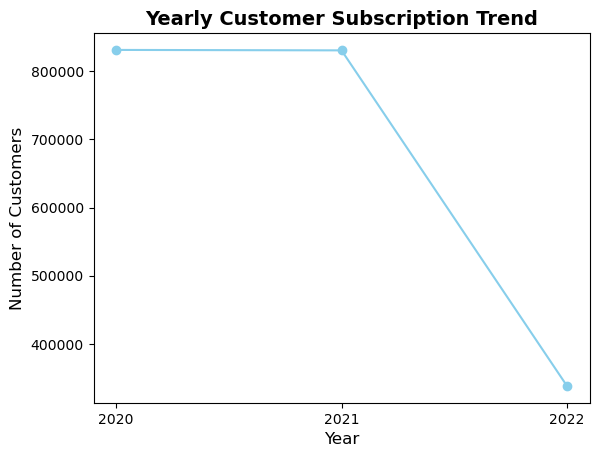

2020    831045
2021    830392
2022    338563
Name: Subscription Date, dtype: int64


In [16]:
yearly_subs = df['Subscription Date'].dt.year.value_counts().sort_index()

plt.plot(yearly_subs.index.astype(str), yearly_subs.values, color='skyblue', marker='o')

plt.title('Yearly Customer Subscription Trend', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.show()
print(yearly_subs)

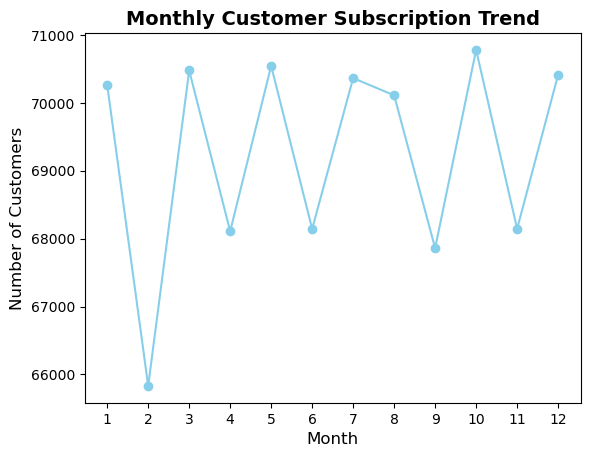

1     70264
2     65831
3     70477
4     68109
5     70545
6     68144
7     70365
8     70111
9     67861
10    70780
11    68145
12    70413
Name: Subscription Date, dtype: int64


In [17]:
chosen_year = int(input("Choose Year: "))

df_filtered = df[df['Subscription Date'].dt.year == chosen_year]

monthly_subs = df_filtered['Subscription Date'].dt.month.value_counts().sort_index()

plt.plot(monthly_subs.index.astype(str), monthly_subs.values, color='skyblue', marker='o')

plt.title('Monthly Customer Subscription Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.show()
print(monthly_subs)